# Ερμηνεία του μοντέλου με SHAP

Το SHAP μοιράζει κάθε πρόβλεψη στους descriptors που τη διαμόρφωσαν:

    βασική τιμή (μέση πρόβλεψη)  +  Σ τιμών SHAP  =  πιθανότητα High

Θετική τιμή SHAP σπρώχνει το μόριο προς High, αρνητική προς Low. Όλες οι τιμές είναι
σε **μονάδες πιθανότητας**, οπότε ένα SHAP 0.02 σημαίνει «+2 ποσοστιαίες μονάδες».

Εξηγείται **το ίδιο μοντέλο** που αξιολογήθηκε στο `test_set_evaluation_final`:

| cutoff | μοντέλο | features |
|---|---|---|
| 50% | ExtraTrees + CatBoost (soft average) | MI ∩ CatBoost, cutoff 50% |
| 20% | ExtraTrees | MI ∩ CatBoost, cutoff 20% |

**Τι περιέχει**

1. Εκπαίδευση του μοντέλου (όλα τα 1142 training μόρια)
2. Υπολογισμός SHAP — training και test set
3. Καθολική σημαντικότητα: bar και beeswarm (training)
4. Dependence plots για τους κορυφαίους descriptors
5. **2D vs 3D** — μερίδιο στη συνεισφορά σε σχέση με το πλήθος
6. Τοπικές εξηγήσεις (waterfall) για χαρακτηριστικά μόρια του test set

**Επιφυλάξεις για την ερμηνεία**

- Οι συσχετισμένοι descriptors μοιράζονται τη συνεισφορά τους, οπότε μπορεί ο καθένας
  να φαίνεται λιγότερο σημαντικός απ' ό,τι είναι η πληροφορία που κουβαλούν μαζί.
- Το SHAP εξηγεί **το μοντέλο**, όχι τη χημεία: δείχνει σε τι βασίζεται η πρόβλεψη,
  όχι τι προκαλεί χαμηλή ή υψηλή βιοδιαθεσιμότητα.
- Στο cutoff 50% το ExtraTrees εξηγείται με `tree_path_dependent` και το CatBoost
  με `interventional` (100 μόρια αναφοράς), ώστε και τα δύο να δίνουν SHAP σε
  πιθανότητες. Και οι δύο μέθοδοι είναι ακριβείς (ο έλεγχος προσθετικότητας στο
  Βήμα 2 το επιβεβαιώνει).


In [15]:
# ============================== ΠΑΡΑΜΕΤΡΟΙ ==============================
label_case = 'label_cutoff_20%'  # 'label_cutoff_50%' | 'label_cutoff_20%'
test_set   = 'Test set 1'        # 'Test set 1' | 'Test set 2'  (για τα τοπικά παραδείγματα)

RANDOM_STATE = 42

# Το ίδιο μοντέλο με το test_set_evaluation_final
MODEL_CHOICE = {
    'label_cutoff_50%': ['ExtraTrees', 'CatBoost'],
    'label_cutoff_20%': ['ExtraTrees'],
}

N_TOP        = 20    # πόσοι descriptors στα διαγράμματα σημαντικότητας
N_DEPENDENCE = 4     # πόσοι descriptors στα dependence plots
N_BACKGROUND = 100   # μόρια αναφοράς για το CatBoost (interventional SHAP)


## Βήμα 1 — Δεδομένα και εκπαίδευση

In [16]:
# ================= ΒΗΜΑ 1 — ΔΕΔΟΜΕΝΑ ΚΑΙ ΕΚΠΑΙΔΕΥΣΗ ΜΟΝΤΕΛΟΥ =================
# Ίδια features, ίδιες υπερπαράμετροι και ίδια εκπαίδευση (όλα τα 1142 μόρια)
# με το test_set_evaluation_final, ώστε το SHAP να εξηγεί ακριβώς το μοντέλο
# που αξιολογήθηκε.
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

TAG      = label_case.replace('label_cutoff_', '').replace('%', '')
TEST_TAG = test_set.replace('Test set ', 'test')
OUT      = f'../results/Label_cutoff_{TAG}%/SHAP'
os.makedirs(OUT, exist_ok=True)

# ---------------------------------------------------------------- features
_feat_file = next(p for p in [f'../Data/final_dataset_{label_case}.xlsx',
                              '../Data/final_dataset_223.xlsx'] if os.path.exists(p))
features = [c for c in pd.read_excel(_feat_file, sheet_name='Dataset', nrows=1).columns
            if c not in ('SMILES', 'smile')]
meta = pd.read_excel(_feat_file, sheet_name='Metadata')      # descriptor | type (2D/3D)

# ---------------------------------------------------------------- training
_train_file = next(p for p in [f'../Data/merged_df_clean_{label_case}.csv',
                               '../Data/merged_df_clean.csv'] if os.path.exists(p))
train = pd.read_csv(_train_file)
train = train[train[label_case].notna()].reset_index(drop=True)
X_train = train[features]
y_train = train[label_case].astype(int).to_numpy()
medians = X_train.median()

# ---------------------------------------------------------------- test set
_sheets = pd.read_excel('../Data/hob_data_set.xlsx', sheet_name=None)
_lab = (_sheets[test_set][['Name', 'smile', label_case]]
        .rename(columns={'smile': 'SMILES'})
        .drop_duplicates(subset='SMILES'))
_desc = pd.read_csv(f'../Data/{TEST_TAG}_descriptors_RAW.csv').drop_duplicates(subset='SMILES')
test = _desc.merge(_lab, on='SMILES', how='inner')
test = test[test[label_case].notna()].reset_index(drop=True)
X_test = test[features].apply(pd.to_numeric, errors='coerce').fillna(medians)
y_test = test[label_case].astype(int).to_numpy()

# ------------------------------------------------------------------ μοντέλα
def build(name):
    if name == 'ExtraTrees':
        est = ExtraTreesClassifier(n_estimators=300, max_features='log2',
                                   min_samples_split=5, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    elif name == 'CatBoost':
        est = CatBoostClassifier(depth=4, learning_rate=0.15, iterations=300,
                                 random_seed=RANDOM_STATE, verbose=0,
                                 auto_class_weights='Balanced', thread_count=-1)
    else:
        raise ValueError(f'άγνωστο μοντέλο: {name}')
    return Pipeline([('scaler', RobustScaler()), ('model', est)])

members = MODEL_CHOICE[label_case]
MODEL_NAME = ' + '.join(members) + (' (soft average)' if len(members) > 1 else '')

fitted = []
for name in members:
    m = build(name)
    m.fit(X_train, y_train)
    fitted.append((name, m))

# --- το κατώφλι της τελικής αξιολόγησης (για να χαρακτηριστούν οι προβλέψεις) ---
_res = (f"../results/Label_cutoff_{TAG}%/Test_evaluation/"
        f"results_{label_case.replace(chr(37), '')}_{TEST_TAG}.csv")
if os.path.exists(_res):
    threshold = float(pd.read_csv(_res)['Threshold'].iloc[0])
    _thr_src = os.path.basename(_res)
else:
    threshold, _thr_src = 0.5, 'δεν βρέθηκε αποτέλεσμα αξιολόγησης — χρησιμοποιείται 0.5'

print(f"Σενάριο   : {label_case}")
print(f"Μοντέλο   : {MODEL_NAME}")
print(f"Features  : {len(features)}  "
      f"(2D: {int((meta['type'] == '2D').sum())}, 3D: {int((meta['type'] == '3D').sum())})")
print(f"Training  : {len(y_train)} μόρια   (High={int(y_train.sum())}, Low={int((y_train == 0).sum())})")
print(f"{test_set}: {len(y_test)} μόρια   (High={int(y_test.sum())}, Low={int((y_test == 0).sum())})")
print(f"Κατώφλι   : {threshold:.3f}   ({_thr_src})")


Σενάριο   : label_cutoff_20%
Μοντέλο   : ExtraTrees
Features  : 232  (2D: 183, 3D: 49)
Training  : 1142 μόρια   (High=859, Low=283)
Test set 1: 287 μόρια   (High=214, Low=73)
Κατώφλι   : 0.713   (results_label_cutoff_20_test1.csv)


## Βήμα 2 — Υπολογισμός τιμών SHAP

Περίπου 2–3 λεπτά για το ExtraTrees στα 1142 μόρια.

In [17]:
# ======================= ΒΗΜΑ 2 — ΥΠΟΛΟΓΙΣΜΟΣ ΤΙΜΩΝ SHAP =======================
# Όλες οι τιμές SHAP είναι σε μονάδες ΠΙΘΑΝΟΤΗΤΑΣ της κλάσης High:
#     base_value + Σ SHAP = προβλεπόμενη πιθανότητα High
#
#   ExtraTrees -> TreeExplainer (tree_path_dependent): ακριβές και γρήγορο.
#                 Τα δέντρα του sklearn δίνουν απευθείας πιθανότητες.
#   CatBoost   -> TreeExplainer (interventional, model_output='probability'),
#                 με N_BACKGROUND training μόρια ως αναφορά. Χωρίς αυτό, το
#                 CatBoost θα έδινε SHAP σε log-odds και δεν θα μπορούσε να
#                 μπει στον ίδιο μέσο όρο με το ExtraTrees.
#
# Για το ensemble (cutoff 50%) η πρόβλεψη είναι ο μέσος όρος των δύο μοντέλων,
# άρα -επειδή το SHAP είναι γραμμικό- και οι τιμές SHAP είναι ο μέσος όρος τους.
import time
import shap

explainers = {}
for name, pipe in fitted:
    mdl = pipe.named_steps['model']
    if name == 'ExtraTrees':
        explainers[name] = shap.TreeExplainer(mdl)
    else:
        _bg = (pd.DataFrame(pipe.named_steps['scaler'].transform(X_train), columns=features)
               .sample(N_BACKGROUND, random_state=RANDOM_STATE))
        explainers[name] = shap.TreeExplainer(mdl, data=_bg,
                                              feature_perturbation='interventional',
                                              model_output='probability')

def compute_shap(X_raw):
    """Τιμές SHAP (πιθανότητα High) για το μοντέλο του σεναρίου."""
    vals, bases = [], []
    for name, pipe in fitted:
        Xs = pd.DataFrame(pipe.named_steps['scaler'].transform(X_raw), columns=features)
        sv = explainers[name](Xs, check_additivity=False)
        v, b = np.asarray(sv.values), np.asarray(sv.base_values)
        if v.ndim == 3:            # (μόρια, features, κλάσεις) -> κλάση High
            v = v[..., 1]
        if b.ndim == 2:
            b = b[:, 1]
        vals.append(v)
        bases.append(np.broadcast_to(b, (len(X_raw),)))
    V, B = np.mean(vals, axis=0), np.mean(bases, axis=0)

    proba = np.mean([pipe.predict_proba(X_raw)[:, 1] for _, pipe in fitted], axis=0)
    err = float(np.max(np.abs(B + V.sum(axis=1) - proba)))
    expl = shap.Explanation(values=V, base_values=B, data=X_raw.to_numpy(),
                            feature_names=features)
    return expl, proba, err

t0 = time.time()
expl_train, proba_train, _err_tr = compute_shap(X_train)
print(f"Training : {expl_train.values.shape}   ({time.time() - t0:.0f}s)")
t0 = time.time()
expl_test, proba_test, _err_te = compute_shap(X_test)
print(f"{test_set}: {expl_test.values.shape}   ({time.time() - t0:.0f}s)")

print(f"\nΈλεγχος προσθετικότητας  max|base + ΣSHAP − πιθανότητα|:")
print(f"  training {_err_tr:.1e}   ·   test {_err_te:.1e}   (≈0 σημαίνει σωστό)")
print(f"Βασική τιμή (μέση πρόβλεψη): {expl_train.base_values.mean():.3f}")

# --- αποθήκευση των τιμών SHAP ---
def _save(df, path):
    try:
        df.to_csv(path, index=False, encoding='utf-8-sig')
        print(f"  {path}")
    except PermissionError:
        print(f"  ⚠ κλειδωμένο, δεν γράφτηκε: {path}")

print("\nΑποθηκεύτηκαν:")
_save(pd.concat([train[['SMILES']],
                 pd.DataFrame(expl_train.values, columns=features)], axis=1),
      f'{OUT}/shap_values_train_cutoff{TAG}.csv')
_save(pd.concat([test[['SMILES']],
                 pd.DataFrame(expl_test.values, columns=features)], axis=1),
      f'{OUT}/shap_values_{TEST_TAG}_cutoff{TAG}.csv')


Training : (1142, 232)   (64s)
Test set 1: (287, 232)   (16s)

Έλεγχος προσθετικότητας  max|base + ΣSHAP − πιθανότητα|:
  training 7.6e-11   ·   test 2.3e-11   (≈0 σημαίνει σωστό)
Βασική τιμή (μέση πρόβλεψη): 0.500

Αποθηκεύτηκαν:
  ../results/Label_cutoff_20%/SHAP/shap_values_train_cutoff20.csv
  ../results/Label_cutoff_20%/SHAP/shap_values_test1_cutoff20.csv


## Βήμα 3 — Καθολική σημαντικότητα

=== Top 20 descriptors κατά μέσο |SHAP| — label_cutoff_20% ===
 rank descriptor type  mean_abs_shap  spearman_value_vs_shap    κατεύθυνση  cumulative_%
    1   MINssssN   2D         0.0054                 -0.2381  ↑ τιμή → Low        1.1294
    2       CIC0   2D         0.0052                 -0.7535  ↑ τιμή → Low        2.2183
    3      DPSA3   3D         0.0052                 -0.4197  ↑ τιμή → Low        3.3035
    4      WPSA3   3D         0.0048                 -0.7586  ↑ τιμή → Low        4.3241
    5      PPSA4   3D         0.0048                 -0.7707  ↑ τιμή → Low        5.3321
    6      MID_X   2D         0.0048                  0.7404 ↑ τιμή → High        6.3353
    7     NssssN   2D         0.0047                 -0.2381  ↑ τιμή → Low        7.3350
    8      WNSA3   3D         0.0047                  0.3731 ↑ τιμή → High        8.3288
    9    ATSC1se   2D         0.0042                  0.1287 ↑ τιμή → High        9.2191
   10      Xc-5d   2D         0.0039           

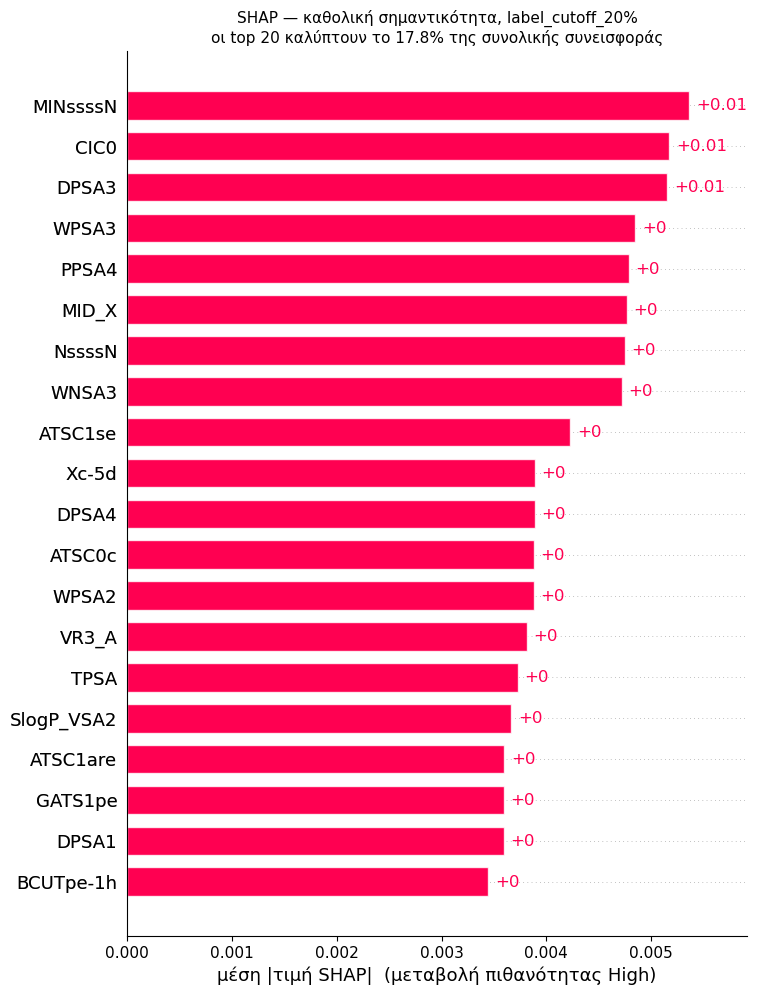

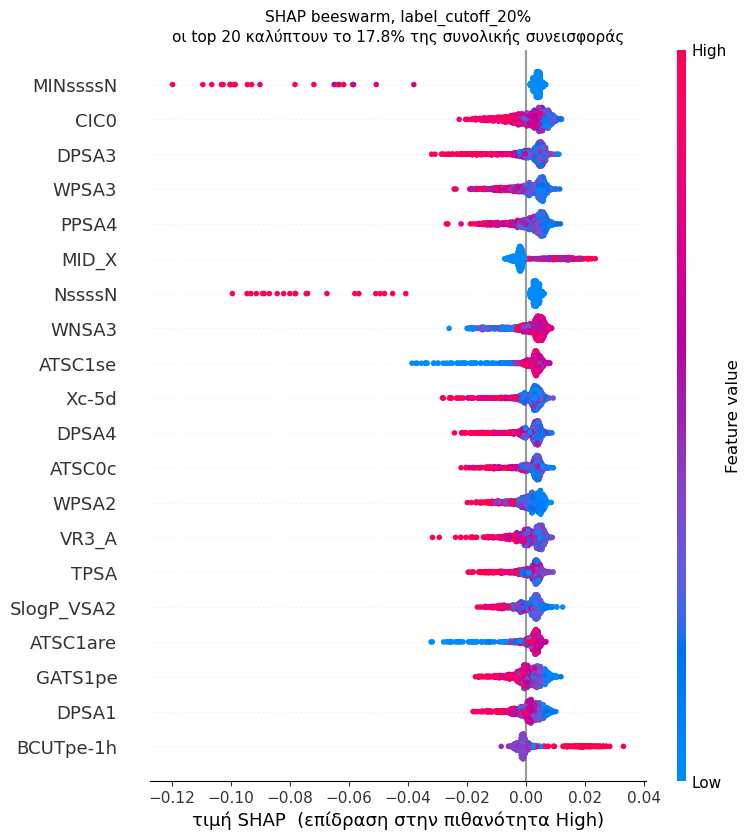

  ../results/Label_cutoff_20%/SHAP/shap_bar_cutoff20.png
  ../results/Label_cutoff_20%/SHAP/shap_beeswarm_cutoff20.png


In [18]:
# ============ ΒΗΜΑ 3 — ΚΑΘΟΛΙΚΗ ΣΗΜΑΝΤΙΚΟΤΗΤΑ (training, 1142 μόρια) ============
from scipy.stats import spearmanr

V = expl_train.values
importance = pd.DataFrame({
    'descriptor':    features,
    'mean_abs_shap': np.abs(V).mean(axis=0),   # μέση |μεταβολή πιθανότητας High|
})

# Κατεύθυνση: όταν μεγαλώνει ο descriptor, ανεβαίνει ή πέφτει η πιθανότητα High;
_rho = []
for j, f in enumerate(features):
    x = X_train[f].to_numpy()
    _rho.append(np.nan if np.nanstd(x) == 0 else spearmanr(x, V[:, j]).statistic)
importance['spearman_value_vs_shap'] = _rho
importance['κατεύθυνση'] = np.select(
    [importance['spearman_value_vs_shap'] > 0.1, importance['spearman_value_vs_shap'] < -0.1],
    ['↑ τιμή → High', '↑ τιμή → Low'], default='μη μονοτονική')

importance = (importance.merge(meta, on='descriptor', how='left')
              .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))
importance.insert(0, 'rank', range(1, len(importance) + 1))
importance['cumulative_%'] = 100 * importance['mean_abs_shap'].cumsum() / importance['mean_abs_shap'].sum()

print(f"=== Top {N_TOP} descriptors κατά μέσο |SHAP| — {label_case} ===")
print(importance.head(N_TOP)[['rank', 'descriptor', 'type', 'mean_abs_shap',
                              'spearman_value_vs_shap', 'κατεύθυνση', 'cumulative_%']]
      .round(4).to_string(index=False))

# Η σημαντικότητα είναι διάχυτη: πόσο από το σύνολο καλύπτουν οι top-N;
_share = importance['cumulative_%'].iloc[N_TOP - 1]
_n50 = int((importance['cumulative_%'] < 50).sum()) + 1
print(f"\nΟι top {N_TOP} descriptors καλύπτουν το {_share:.1f}% της συνολικής συνεισφοράς SHAP.")
print(f"Για το 50% της συνεισφοράς χρειάζονται οι top {_n50} από τους {len(features)}.")

print("\nΑποθηκεύτηκε:")
_save(importance.round(6), f'{OUT}/shap_importance_cutoff{TAG}.csv')

# Τα διαγράμματα δείχνουν μόνο τους top-N — χωρίς τη γραμμή «Sum of other
# features», που αλλιώς θα κυριαρχούσε στον άξονα.
_top_idx  = [features.index(d) for d in importance['descriptor'].head(N_TOP)]
expl_top  = expl_train[:, _top_idx]
_subtitle = f'οι top {N_TOP} καλύπτουν το {_share:.1f}% της συνολικής συνεισφοράς'

# ------------------------------------------------------------------ bar plot
plt.figure()
shap.plots.bar(expl_top, max_display=N_TOP, show=False)
plt.title(f'SHAP — καθολική σημαντικότητα, {label_case}\n{_subtitle}', fontsize=11)
plt.xlabel('μέση |τιμή SHAP|  (μεταβολή πιθανότητας High)')
plt.gcf().savefig(f'{OUT}/shap_bar_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------- beeswarm plot
plt.figure()
shap.plots.beeswarm(expl_top, max_display=N_TOP, show=False)
plt.title(f'SHAP beeswarm, {label_case}\n{_subtitle}', fontsize=11)
plt.xlabel('τιμή SHAP  (επίδραση στην πιθανότητα High)')
plt.gcf().savefig(f'{OUT}/shap_beeswarm_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"  {OUT}/shap_bar_cutoff{TAG}.png\n  {OUT}/shap_beeswarm_cutoff{TAG}.png")


## Βήμα 4 — Dependence plots

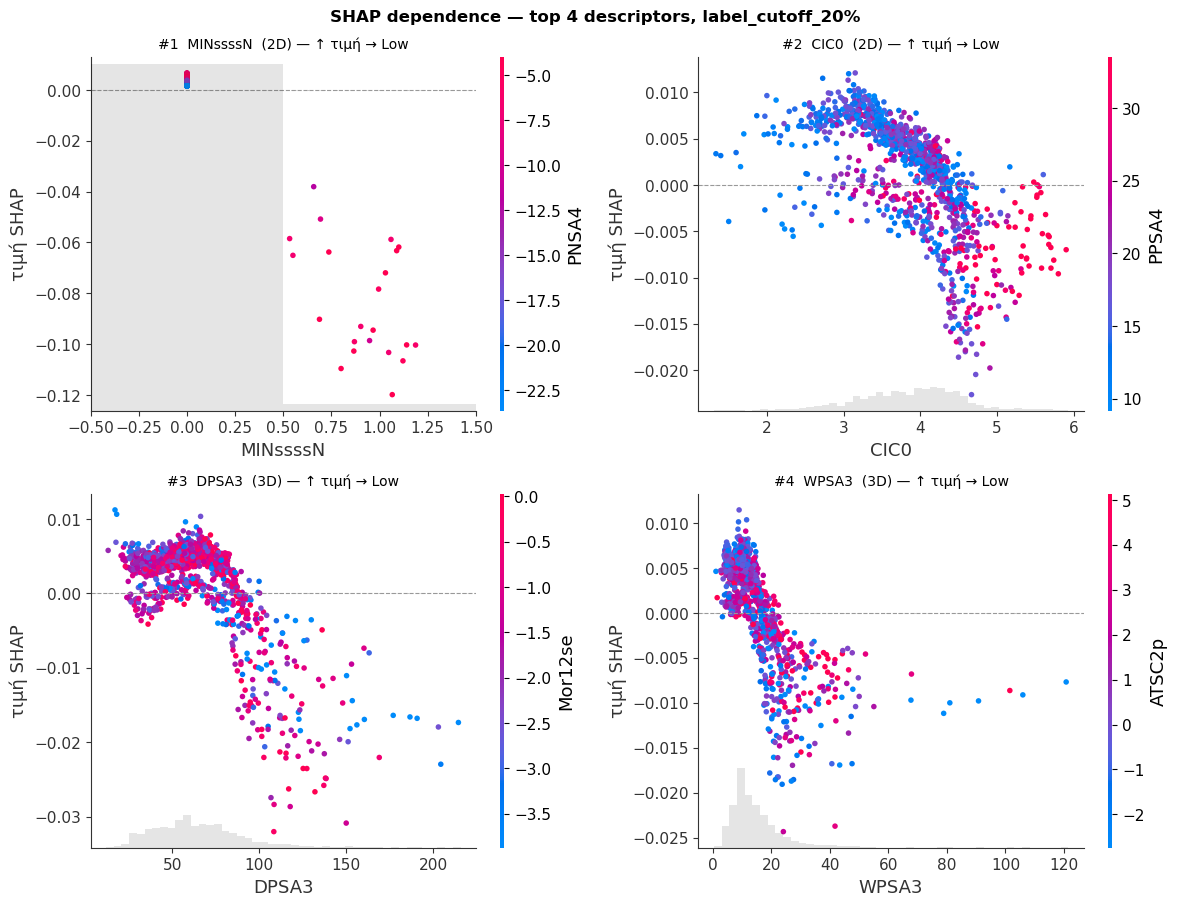

Αποθηκεύτηκε: ../results/Label_cutoff_20%/SHAP/shap_dependence_cutoff20.png


In [19]:
# ============== ΒΗΜΑ 4 — DEPENDENCE PLOTS (top descriptors, training) ==============
# Κάθε τελεία ένα μόριο: x = τιμή του descriptor, y = η τιμή SHAP του.
# Το χρώμα είναι ο descriptor με την ισχυρότερη αλληλεπίδραση (επιλογή του shap).
top_feats = importance['descriptor'].head(N_DEPENDENCE).tolist()

ncols = 2
nrows = int(np.ceil(len(top_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4.6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, f in zip(axes, top_feats):
    shap.plots.scatter(expl_train[:, f], color=expl_train, ax=ax, show=False)
    _r = importance.loc[importance['descriptor'] == f].iloc[0]
    ax.set_title(f"#{int(_r['rank'])}  {f}  ({_r['type']}) — {_r['κατεύθυνση']}", fontsize=10)
    ax.axhline(0, color='#999999', lw=0.8, ls='--')
    ax.set_ylabel('τιμή SHAP')
for ax in axes[len(top_feats):]:
    ax.set_visible(False)

fig.suptitle(f'SHAP dependence — top {len(top_feats)} descriptors, {label_case}',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUT}/shap_dependence_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Αποθηκεύτηκε: {OUT}/shap_dependence_cutoff{TAG}.png")


## Βήμα 5 — 2D vs 3D descriptors

=== 2D vs 3D — label_cutoff_20% ===
type     σύνολο  n_descriptors  sum_mean_abs_shap  % descriptors  % συνεισφοράς  λόγος (συνεισφ./πλήθος)  μέσο |SHAP| ανά descriptor  στο top-20
  2D   training            183              0.359         78.879         75.640                    0.959                       0.002          12
  3D   training             49              0.116         21.121         24.360                    1.153                       0.002           8
  2D Test set 1            183              0.303         78.879         75.715                    0.960                       0.002          13
  3D Test set 1             49              0.097         21.121         24.285                    1.150                       0.002           7

Αποθηκεύτηκε:
  ../results/Label_cutoff_20%/SHAP/shap_2d_vs_3d_cutoff20.csv


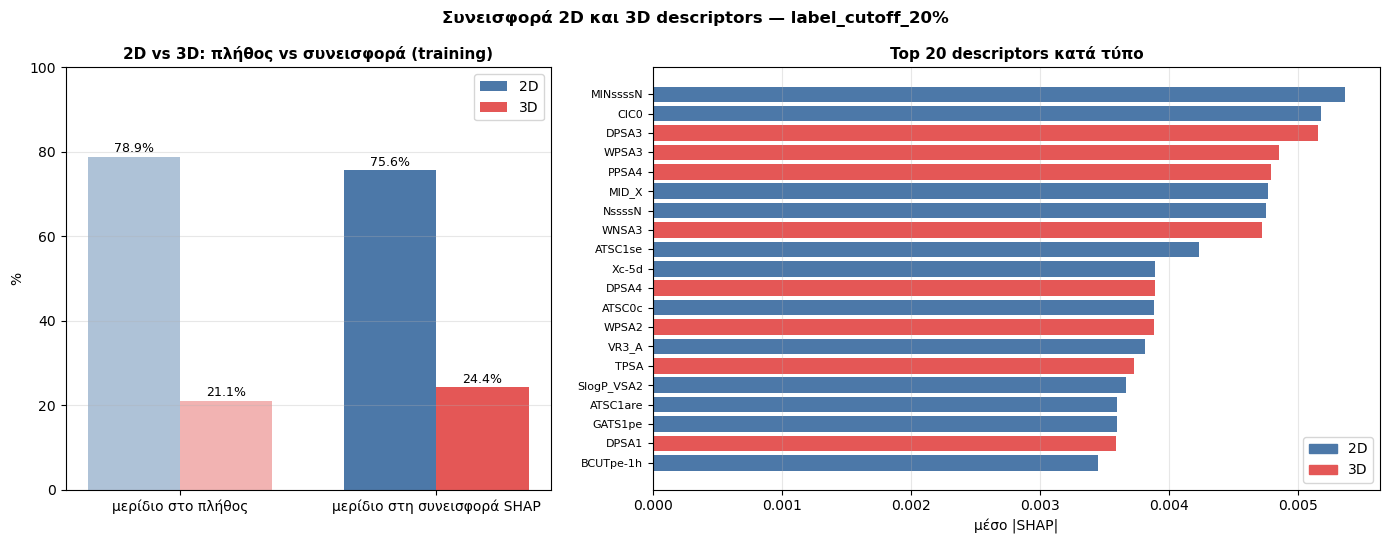

  ../results/Label_cutoff_20%/SHAP/shap_2d_vs_3d_cutoff20.png


In [20]:
# ==================== ΒΗΜΑ 5 — 2D vs 3D DESCRIPTORS ====================
# Πόση από τη συνολική συνεισφορά (Σ μέσου |SHAP|) προέρχεται από τους 3D
# descriptors, σε σχέση με το πόσοι είναι; Λόγος > 1 σημαίνει ότι μετράνε
# περισσότερο από όσο θα περίμενε κανείς από το πλήθος τους.
def dim_summary(expl, label):
    imp = pd.DataFrame({'descriptor': features,
                        'mean_abs_shap': np.abs(expl.values).mean(axis=0)}).merge(meta, on='descriptor')
    g = imp.groupby('type').agg(n_descriptors=('descriptor', 'size'),
                                sum_mean_abs_shap=('mean_abs_shap', 'sum'))
    g['% descriptors']          = 100 * g['n_descriptors'] / g['n_descriptors'].sum()
    g['% συνεισφοράς']          = 100 * g['sum_mean_abs_shap'] / g['sum_mean_abs_shap'].sum()
    g['λόγος (συνεισφ./πλήθος)'] = g['% συνεισφοράς'] / g['% descriptors']
    g['μέσο |SHAP| ανά descriptor'] = g['sum_mean_abs_shap'] / g['n_descriptors']
    _top = imp.sort_values('mean_abs_shap', ascending=False).head(N_TOP)
    g[f'στο top-{N_TOP}'] = _top.groupby('type').size().reindex(g.index).fillna(0).astype(int)
    g.insert(0, 'σύνολο', label)
    return g.reset_index()

dim_train = dim_summary(expl_train, 'training')
dim_test  = dim_summary(expl_test, test_set)
dim_table = pd.concat([dim_train, dim_test], ignore_index=True)

print(f"=== 2D vs 3D — {label_case} ===")
print(dim_table.round(3).to_string(index=False))

print("\nΑποθηκεύτηκε:")
_save(dim_table.round(4), f'{OUT}/shap_2d_vs_3d_cutoff{TAG}.csv')

# ---------------------------------------------------------------- διάγραμμα
_c = {'2D': '#4C78A8', '3D': '#E45756'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5),
                               gridspec_kw={'width_ratios': [1, 1.5]})

# αριστερά: μερίδιο στο πλήθος vs μερίδιο στη συνεισφορά
_d = dim_train.set_index('type')
_x = np.arange(2)
for k, t in enumerate(['2D', '3D']):
    if t not in _d.index:
        continue
    ax1.bar(_x[0] + (k - 0.5) * 0.36, _d.loc[t, '% descriptors'], width=0.36,
            color=_c[t], alpha=0.45)
    ax1.bar(_x[1] + (k - 0.5) * 0.36, _d.loc[t, '% συνεισφοράς'], width=0.36,
            color=_c[t], label=t)
    for xi, col in [(0, '% descriptors'), (1, '% συνεισφοράς')]:
        v = _d.loc[t, col]
        ax1.text(_x[xi] + (k - 0.5) * 0.36, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
ax1.set_xticks(_x)
ax1.set_xticklabels(['μερίδιο στο πλήθος', 'μερίδιο στη συνεισφορά SHAP'])
ax1.set_ylabel('%'); ax1.set_ylim(0, 100)
ax1.set_title('2D vs 3D: πλήθος vs συνεισφορά (training)', fontsize=11, fontweight='bold')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# δεξιά: top descriptors, χρωματισμένοι κατά τύπο
_t = importance.head(N_TOP).iloc[::-1]
ax2.barh(_t['descriptor'], _t['mean_abs_shap'], color=[_c.get(t, '#999999') for t in _t['type']])
ax2.set_xlabel('μέσο |SHAP|')
ax2.set_title(f'Top {N_TOP} descriptors κατά τύπο', fontsize=11, fontweight='bold')
ax2.tick_params(axis='y', labelsize=8)
ax2.grid(axis='x', alpha=0.3)
ax2.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=_c[t]) for t in ['2D', '3D']],
           labels=['2D', '3D'], loc='lower right')

fig.suptitle(f'Συνεισφορά 2D και 3D descriptors — {label_case}', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUT}/shap_2d_vs_3d_cutoff{TAG}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"  {OUT}/shap_2d_vs_3d_cutoff{TAG}.png")


## Βήμα 6 — Τοπικές εξηγήσεις σε μόρια του test set

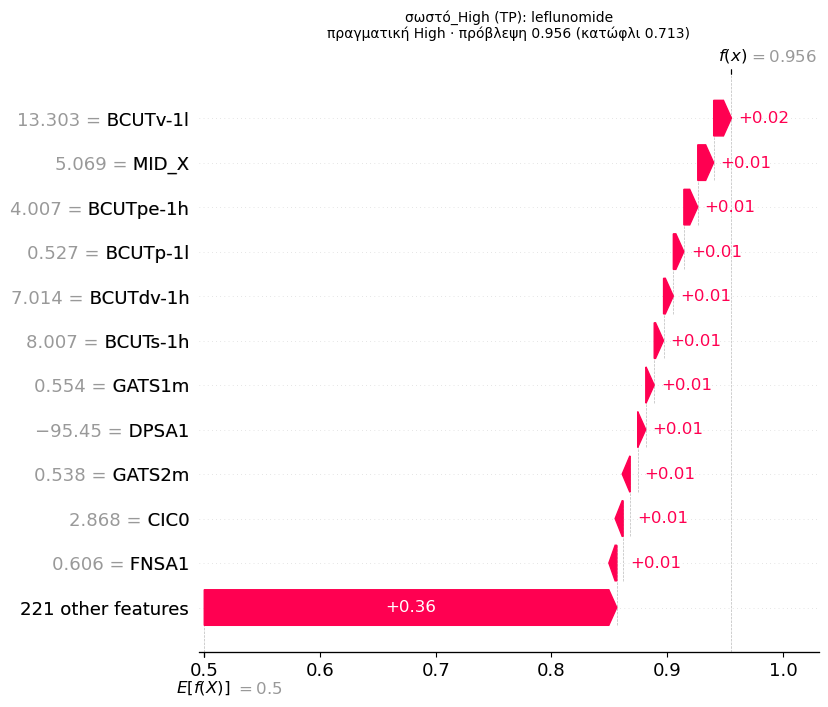

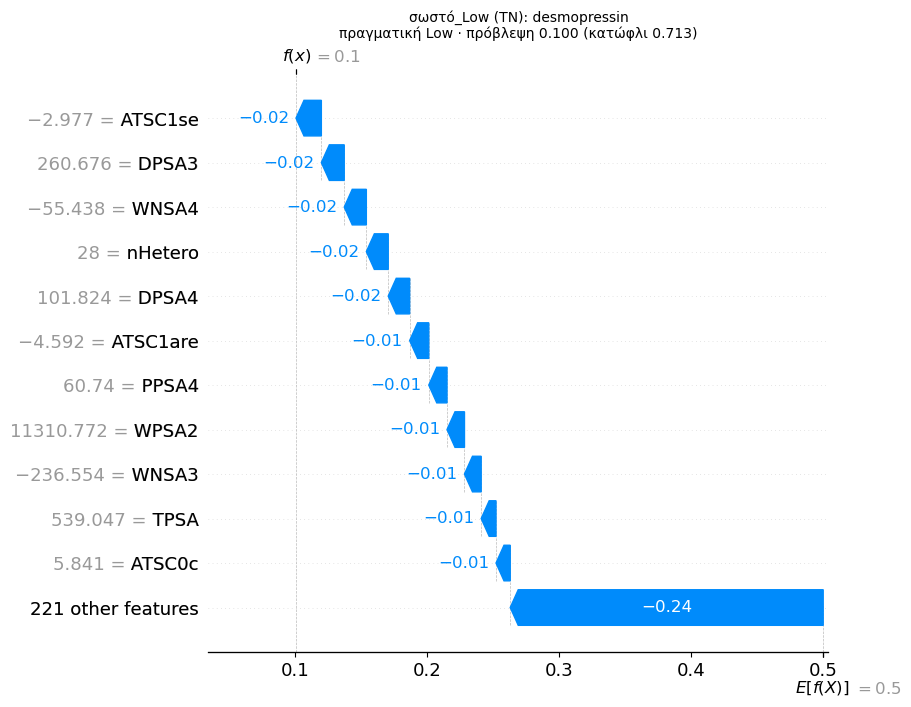

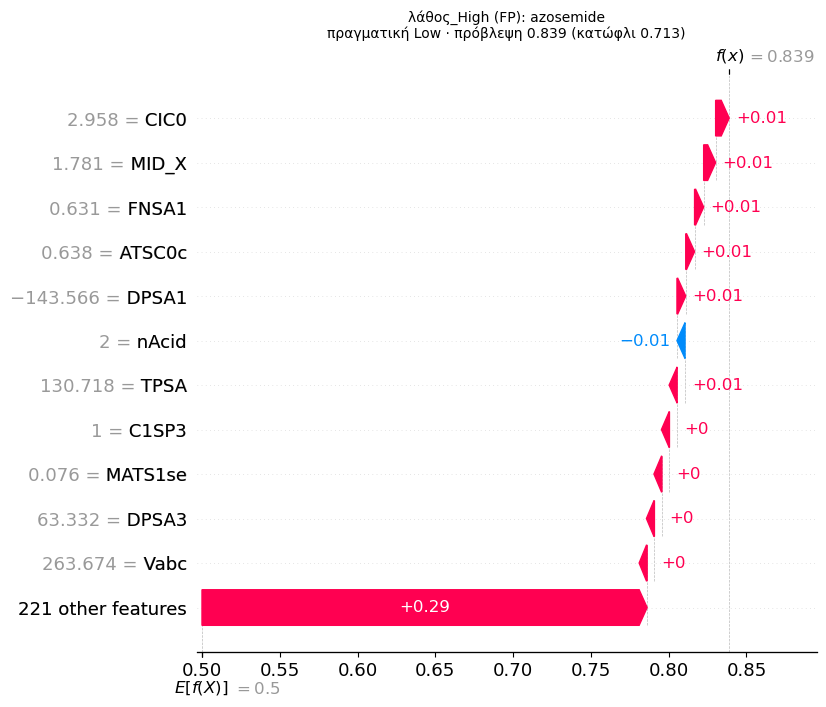

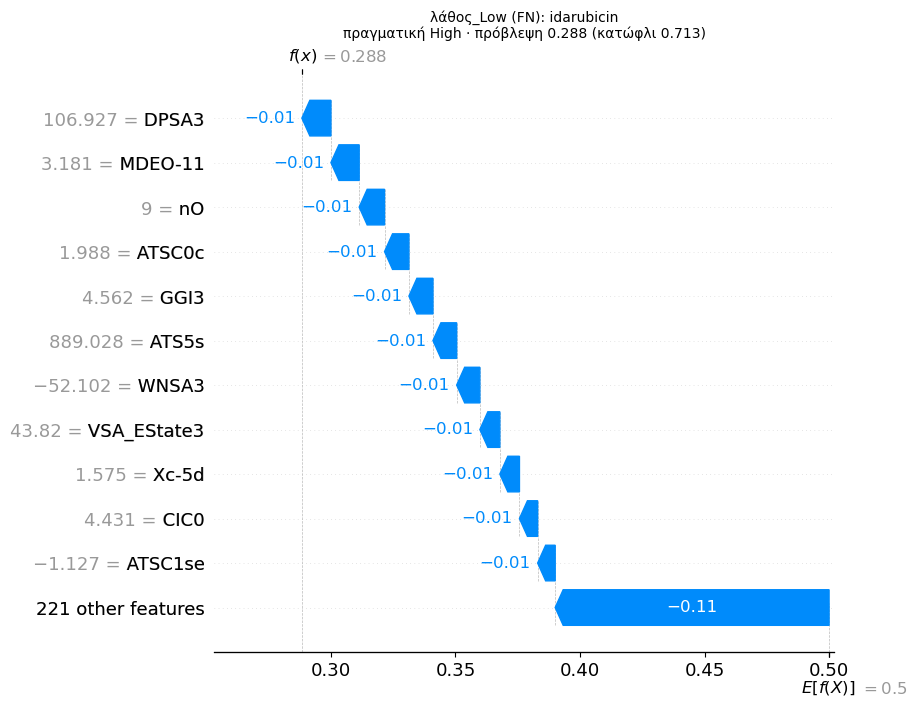

=== Χαρακτηριστικά μόρια — Test set 1, label_cutoff_20% ===
      περίπτωση         Name πραγματική  proba_High                                     top-3 descriptors
σωστό_High (TP)  leflunomide       High       0.956 BCUTv-1l (+0.015), MID_X (+0.014), BCUTpe-1h (+0.012)
 σωστό_Low (TN) desmopressin        Low       0.100      ATSC1se (-0.019), DPSA3 (-0.017), WNSA4 (-0.017)
λάθος_High (FP)    azosemide        Low       0.839         CIC0 (+0.009), MID_X (+0.008), FNSA1 (+0.006)
 λάθος_Low (FN)   idarubicin       High       0.288         DPSA3 (-0.012), MDEO-11 (-0.011), nO (-0.010)

Αποθηκεύτηκε:
  ../results/Label_cutoff_20%/SHAP/shap_examples_test1_cutoff20.csv


In [21]:
# ============ ΒΗΜΑ 6 — ΤΟΠΙΚΕΣ ΕΞΗΓΗΣΕΙΣ: ΜΟΡΙΑ ΤΟΥ TEST SET ============
# Τέσσερα χαρακτηριστικά μόρια, με το κατώφλι της τελικής αξιολόγησης:
#   σωστό High (πιο σίγουρο), σωστό Low (πιο σίγουρο),
#   λάθος High (Low που προβλέφθηκε High με τη μεγαλύτερη βεβαιότητα),
#   λάθος Low  (High που προβλέφθηκε Low με τη μεγαλύτερη βεβαιότητα).
pred_test = (proba_test >= threshold).astype(int)

_cases = {
    'σωστό_High (TP)': (y_test == 1) & (pred_test == 1), 'σωστό_Low (TN)': (y_test == 0) & (pred_test == 0),
    'λάθος_High (FP)': (y_test == 0) & (pred_test == 1), 'λάθος_Low (FN)': (y_test == 1) & (pred_test == 0),
}
_pick = {  # πιο «ακραίο» μόριο κάθε περίπτωσης
    'σωστό_High (TP)': np.argmax, 'σωστό_Low (TN)': np.argmin,
    'λάθος_High (FP)': np.argmax, 'λάθος_Low (FN)': np.argmin,
}

rows = []
for case, mask in _cases.items():
    idx = np.where(mask)[0]
    if len(idx) == 0:
        print(f"{case}: κανένα μόριο")
        continue
    i = idx[_pick[case](proba_test[idx])]
    contrib = pd.Series(expl_test.values[i], index=features)
    top3 = contrib.abs().sort_values(ascending=False).head(3).index
    rows.append({'περίπτωση': case, 'Name': test.loc[i, 'Name'], 'SMILES': test.loc[i, 'SMILES'],
                 'πραγματική': 'High' if y_test[i] else 'Low',
                 'proba_High': round(float(proba_test[i]), 3),
                 'top-3 descriptors': ', '.join(f"{d} ({contrib[d]:+.3f})" for d in top3)})

    plt.figure()
    shap.plots.waterfall(expl_test[i], max_display=12, show=False)
    plt.title(f"{case}: {test.loc[i, 'Name']}\n"
              f"πραγματική {'High' if y_test[i] else 'Low'} · πρόβλεψη {proba_test[i]:.3f} "
              f"(κατώφλι {threshold:.3f})", fontsize=10)
    _fn = case.split(' ')[0]
    plt.gcf().savefig(f'{OUT}/shap_waterfall_{_fn}_{TEST_TAG}_cutoff{TAG}.png',
                      dpi=200, bbox_inches='tight')
    plt.show()

examples = pd.DataFrame(rows)
print(f"=== Χαρακτηριστικά μόρια — {test_set}, {label_case} ===")
print(examples.drop(columns='SMILES').to_string(index=False))

print("\nΑποθηκεύτηκε:")
_save(examples, f'{OUT}/shap_examples_{TEST_TAG}_cutoff{TAG}.csv')
